# Parte 1:

## Análisis exploratorio breve de la temperatura mensual promededio (en Celsius) para 35 estaciones climáticas en Canadá

### Contexto
El interés del análisis es comparar las estaciones entre sí con base en sus curvas de
temperatura. Cada estación tiene 12 mediciones (una por mes). Esto significa que los datos tienen 35 observaciones (estaciones) y 12 variables (meses)

### Características esperadas:

Las temperaturas deberían ser más bajas en los meses de invierno (diciembre, enero, febrero) y más altas en los meses de verano (junio, julio, agosto).

Las estaciones en el norte de Canadá probablemente tendrán temperaturas más frías en general que las del sur.


In [ ]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Cargar los datos
data = pd.read_csv('datasets/weather.csv')  
print(data.head())  

# Información básica del dataset
print("\nInformación del dataset:")
print(data.info())

# Estadísticas descriptivas
print("\nEstadísticas descriptivas:")
print(data.describe())

     0    1    2    3    4     5     6     7     8    9   10   11  \
0 -3.9 -4.5 -2.3  1.2  5.4  10.9  15.5  15.3  11.6  6.9  3.4 -1.5   
1 -7.1 -7.5 -3.1  2.3  8.5  14.5  18.3  17.8  13.5  8.1  2.9 -3.9   
2 -6.0 -6.1 -1.6  3.3  9.2  14.8  18.2  18.1  13.8  8.6  3.4 -2.9   
3 -4.7 -5.9 -2.5  2.0  7.4  13.2  17.7  17.6  13.5  8.4  3.8 -1.8   
4 -2.7 -3.2  0.3  4.7  9.2  13.4  16.3  16.4  13.6  9.5  5.2 -0.3   

         station  
0     St. John’s  
1  Charlottetown  
2        Halifax  
3         Sydney  
4       Yarmouth  

Información del dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   0        35 non-null     float64
 1   1        35 non-null     float64
 2   2        35 non-null     float64
 3   3        35 non-null     float64
 4   4        35 non-null     float64
 5   5        35 non-null     float64
 6   6        35 non-null     float64


In [8]:
# ## 2. Preparar los Datos para PCA
# Separar los nombres de las estaciones de las temperaturas.
# Centrar los datos (restar la media) para el análisis de PCA.

# Separar los nombres de las estaciones y las temperaturas
stations = data['station']  # Nombres de las estaciones
temperatures = data.drop('station', axis=1)  # Temperaturas mensuales

# Centrar los datos (restar la media)
scaler = StandardScaler(with_std=False)  # Solo centrar, no escalar
temperatures_centered = scaler.fit_transform(temperatures)

# ## 3. Aplicar PCA

# Aplicar PCA para reducir la dimensionalidad a 2 componentes principales.
# Obtener las componentes principales y proyectar los datos.

# Aplicar PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(temperatures_centered)

# Mostrar las componentes principales
print("Componentes principales (autovectores):")
print(pca.components_)

print("\nVarianza explicada por cada componente:")
print(pca.explained_variance_ratio_)



Componentes principales (autovectores):
[[ 0.41023272  0.40056341  0.38089354  0.29414608  0.19531453  0.12838622
   0.1092565   0.1306884   0.18056469  0.24526856  0.33634356  0.38745551]
 [-0.39639192 -0.21877508  0.03174789  0.32379219  0.402549    0.40135723
   0.35529445  0.29617856  0.19830242  0.14483389 -0.06338357 -0.29623335]]

Varianza explicada por cada componente:
[0.89327659 0.08341326]


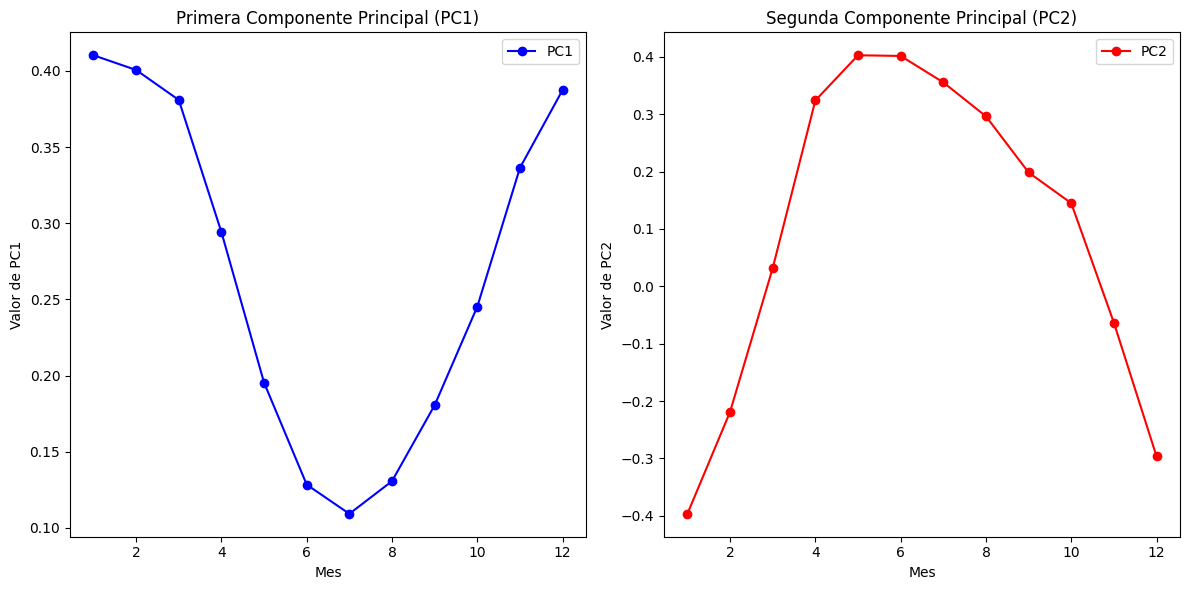

In [ ]:

# Graficar la primera y segunda componente principal como curvas de temperatura a lo largo de los meses.

# Graficar las componentes principales
months = np.arange(1, 13)  # Meses del 1 al 12
plt.figure(figsize=(12, 6))

# Primera componente principal
plt.subplot(1, 2, 1)
plt.plot(months, pca.components_[0], marker='o', color='b', label='PC1')
plt.title('Primera Componente Principal (PC1)')
plt.xlabel('Mes')
plt.ylabel('Valor de PC1')
plt.legend()

# Segunda componente principal
plt.subplot(1, 2, 2)
plt.plot(months, pca.components_[1], marker='o', color='r', label='PC2')
plt.title('Segunda Componente Principal (PC2)')
plt.xlabel('Mes')
plt.ylabel('Valor de PC2')
plt.legend()

plt.tight_layout()
plt.show()

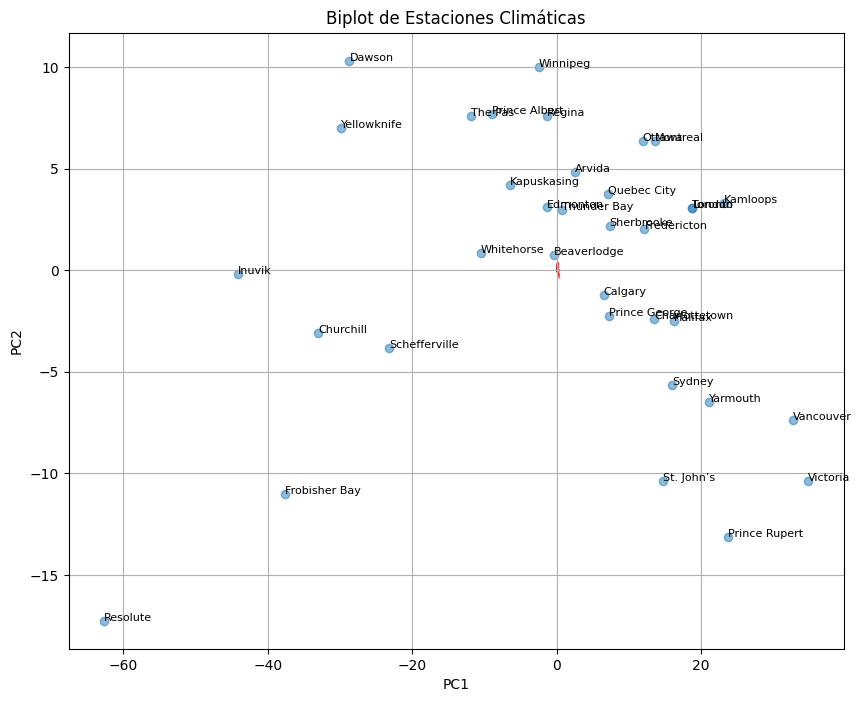

In [16]:

# Crear el biplot
plt.figure(figsize=(10, 8))
plt.scatter(principal_components[:, 0], principal_components[:, 1], alpha=0.5)


for i, station in enumerate(stations):
    plt.text(principal_components[i, 0], principal_components[i, 1], station, fontsize=8)

for j in range(12):
    plt.arrow(0, 0, pca.components_[0, j], pca.components_[1, j], color='r', alpha=0.5)
    

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Biplot de Estaciones Climáticas')
plt.grid()
plt.show()

# Parte 2:

## Análisis de Delitos en EE.UU (1970) mediante Escalamiento Multidimensional

### Contexto
Se analiza una base de datos de actos delictivos en EE.UU. del año 1970. La tabla `crimes.dat` contiene correlaciones entre la ocurrencia de 7 clases de delitos.

### Definición de Distancia
Para cada par de delitos (clases), se define la distancia como:

$$
d(x_i, x_j) = 1 - \rho_{ij}
$$

### Objetivo
Aplicar **escalamiento multidimensional (MDS)** para visualizar las observaciones en un espacio de menor dimensión e interpretar el primer eje principal.

### Importar y visualizar los datos

In [19]:
import pandas as pd

# Importar el archivo crimes.dat. Ajusta el parámetro sep si es necesario (aquí se asume que es CSV separado por comas)
df = pd.read_csv("datasets/crimes.dat", sep=",", skipinitialspace=True)

# Visualizamos el DataFrame importado
print("Datos importados:")
print(df.head())

# Configuramos la columna 'Crime' como índice para trabajar cómodamente
df.set_index("Crime", inplace=True)
print("\nDataFrame con índice 'Crime':")
print(df)


Datos importados:
      Crime  No.     1     2     3     4     5     6     7
0    Murder    1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
1      Rape    2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
2   Robbery    3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
3   Assault    4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
4  Burglary    5  0.28  0.68  0.62  0.52  1.00  0.80  0.70

DataFrame con índice 'Crime':
            No.     1     2     3     4     5     6     7
Crime                                                    
Murder        1  1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape          2  0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery       3  0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault       4  0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary      5  0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny       6  0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft    7  0.11  0.44  0.62  0.33  0.70  0.55  1.00


### Preparación de la matriz de correlaciones

In [20]:
# La tabla incluye una columna "No.", que no es necesaria para el análisis de correlación. La eliminamos.
correlation_matrix = df.drop(columns=["No."]).astype(float)
print("\nMatriz de correlaciones:")
print(correlation_matrix)



Matriz de correlaciones:
               1     2     3     4     5     6     7
Crime                                               
Murder      1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape        0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery     0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault     0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary    0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny     0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft  0.11  0.44  0.62  0.33  0.70  0.55  1.00


Matriz de correlaciones:
               1     2     3     4     5     6     7
Crime                                               
Murder      1.00  0.52  0.34  0.81  0.28  0.06  0.11
Rape        0.52  1.00  0.55  0.70  0.68  0.60  0.44
Robbery     0.34  0.55  1.00  0.56  0.62  0.44  0.62
Assault     0.81  0.70  0.56  1.00  0.52  0.32  0.33
Burglary    0.28  0.68  0.62  0.52  1.00  0.80  0.70
Larceny     0.06  0.60  0.44  0.32  0.80  1.00  0.55
Auto theft  0.11  0.44  0.62  0.33  0.70  0.55  1.00


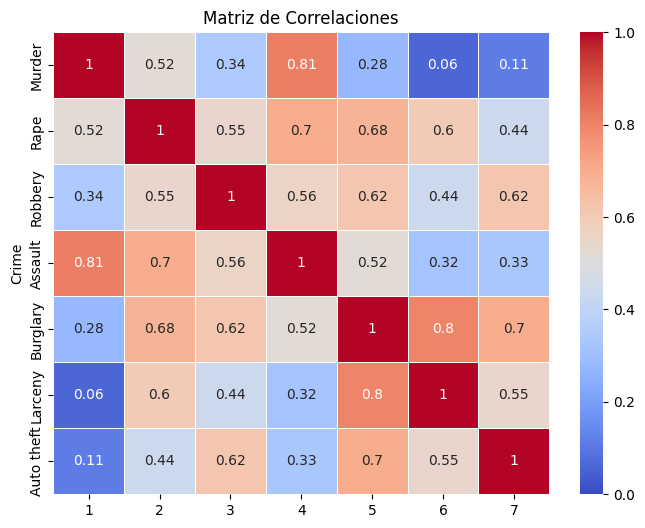

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Suponiendo que correlation_matrix ya está definida
# correlation_matrix = df.drop(columns=["No."]).astype(float)

# Mostrar la matriz de correlaciones
print("Matriz de correlaciones:")
print(correlation_matrix)

# Crear el mapa de calor
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlaciones')
plt.show()

### Cálculo de la matriz de distancias

In [13]:
# Definimos la distancia entre dos variables como: distancia = 1 - correlación
distance_matrix = 1 - correlation_matrix
print("\nMatriz de distancias:")
print(distance_matrix)


Matriz de distancias:
               1     2     3     4     5     6     7
Crime                                               
Murder      0.00  0.48  0.66  0.19  0.72  0.94  0.89
Rape        0.48  0.00  0.45  0.30  0.32  0.40  0.56
Robbery     0.66  0.45  0.00  0.44  0.38  0.56  0.38
Assault     0.19  0.30  0.44  0.00  0.48  0.68  0.67
Burglary    0.72  0.32  0.38  0.48  0.00  0.20  0.30
Larceny     0.94  0.40  0.56  0.68  0.20  0.00  0.45
Auto theft  0.89  0.56  0.38  0.67  0.30  0.45  0.00


### Aplicación de MDS


Coordenadas MDS:
                Dim1      Dim2
Crime                         
Murder      0.209602  0.490927
Rape       -0.102982  0.131432
Robbery     0.238000 -0.145618
Assault     0.125229  0.283502
Burglary   -0.145242 -0.151237
Larceny    -0.350925 -0.203749
Auto theft  0.026318 -0.405257


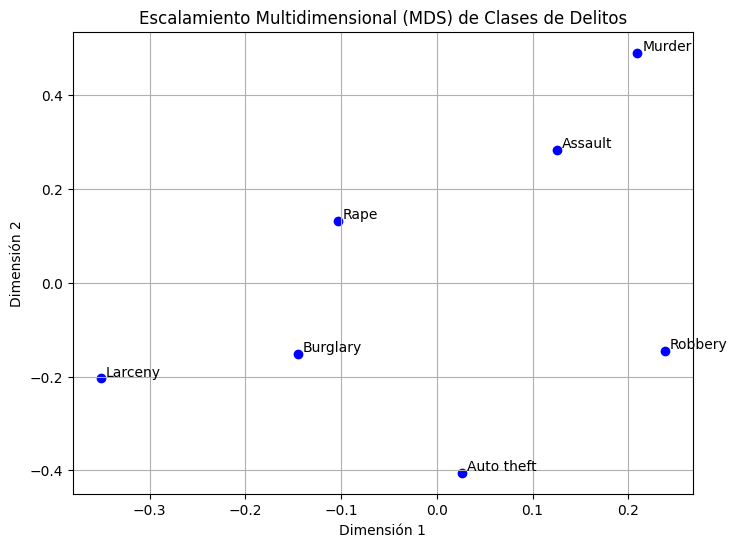

In [14]:
from sklearn.manifold import MDS
import matplotlib.pyplot as plt

# Configuramos y aplicamos el MDS utilizando la matriz de distancias
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
mds_results = mds.fit_transform(distance_matrix)

# Creamos un DataFrame con las coordenadas obtenidas
mds_df = pd.DataFrame(mds_results, columns=["Dim1", "Dim2"], index=correlation_matrix.index)
print("\nCoordenadas MDS:")
print(mds_df)

# Visualización de los resultados
plt.figure(figsize=(8, 6))
plt.scatter(mds_df["Dim1"], mds_df["Dim2"], color="blue")
for crime in mds_df.index:
    plt.text(mds_df.loc[crime, "Dim1"] + 0.005, mds_df.loc[crime, "Dim2"] + 0.005, crime)
plt.title("Escalamiento Multidimensional (MDS) de Clases de Delitos")
plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.grid(True)
plt.show()


### Interpretación del Primer Eje Principal con PCA


Cargas PCA:
                 PC1       PC2
Crime                         
Murder      0.591595  0.073182
Rape        0.038288  0.516457
Robbery    -0.117235 -0.414929
Assault     0.379742  0.146707
Burglary   -0.328993  0.269361
Larceny    -0.457468  0.543325
Auto theft -0.416039 -0.408009


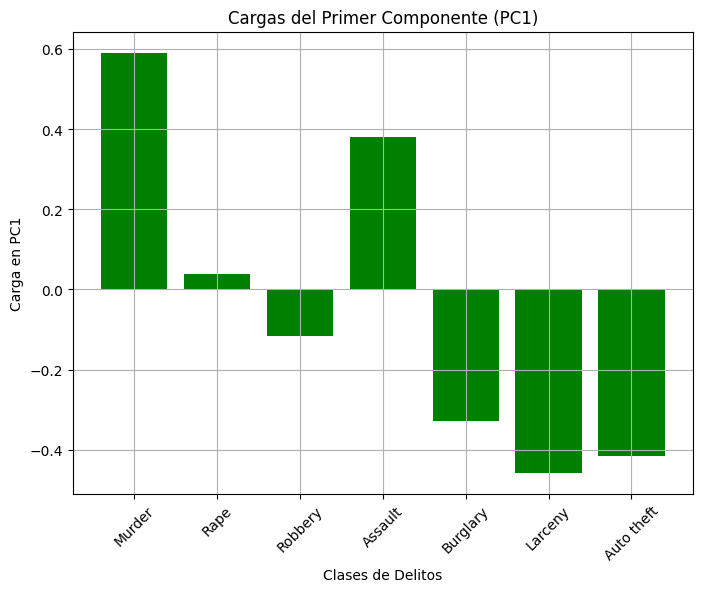

In [15]:
from sklearn.decomposition import PCA

# Aplicamos PCA sobre la matriz de correlación para interpretar el primer eje principal.
pca = PCA(n_components=2)
pca_results = pca.fit_transform(correlation_matrix)

# Creamos un DataFrame para visualizar las cargas de cada variable en los componentes
pca_df = pd.DataFrame(pca.components_.T, index=correlation_matrix.index, columns=["PC1", "PC2"])
print("\nCargas PCA:")
print(pca_df)

# Visualizamos las cargas del primer componente
plt.figure(figsize=(8, 6))
plt.bar(pca_df.index, pca_df["PC1"], color="green")
plt.title("Cargas del Primer Componente (PC1)")
plt.xlabel("Clases de Delitos")
plt.ylabel("Carga en PC1")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()


# Parte 3:

## Compresión de Imágenes mediante PCA aplicada a bloques (usando SVD)

### Contexto

Se subdivide una imagen (en escala de grises) en bloques de tamaño \(C \times C\). Cada bloque se vectoriza y se forma la matriz \(X\), donde cada fila es un bloque. Aplicamos SVD (equivalente a PCA) sobre \(X\) y reconstruimos cada bloque usando solo los primeros \( k \) componentes. Luego reensamblamos la imagen completa y evaluamos el efecto de \( k \) sobre la calidad y el error de reconstrucción.

### Objetivo

Comparar la imagen reconstruida para distintos valores de \( k \) y calcular el error (MSE) en la reconstrucción.

### Importación de librerías y carga de la imagen

Dimensiones de la imagen (grayscale): (764, 1368)


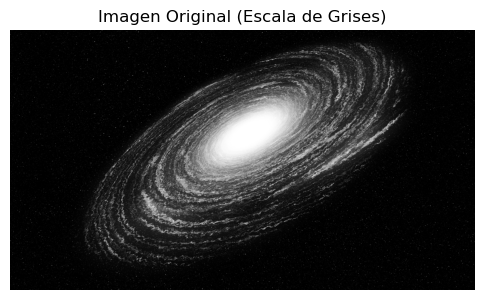

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.color import rgb2gray

# Cargamos la imagen (asegúrate de que 'quetzal.png' esté en el directorio de trabajo)
I = plt.imread('Space1.png')
# Si la imagen tiene canal alfa o más de 3 canales, tomamos los 3 primeros
if I.ndim == 3 and I.shape[2] > 3:
    I = I[:, :, :3]

# Convertimos a escala de grises
Igray = rgb2gray(I)
print("Dimensiones de la imagen (grayscale):", Igray.shape)

# Visualizamos la imagen original
plt.figure(figsize=(6,6))
plt.imshow(Igray, cmap='gray')
plt.title("Imagen Original (Escala de Grises)")
plt.axis('off')
plt.show()


### Función para extraer bloques de la imagen

Se divide la imagen en bloques de tamaño \(C \times C\) y se vectoriza cada bloque.

In [2]:
def extract_blocks(img, block_size):
    H, W = img.shape
    C = block_size
    n_blocks_vertical = H // C
    n_blocks_horizontal = W // C
    blocks = []
    for i in range(n_blocks_vertical):
        for j in range(n_blocks_horizontal):
            block = img[i*C:(i+1)*C, j*C:(j+1)*C]
            blocks.append(block.flatten())
    return np.array(blocks), n_blocks_vertical, n_blocks_horizontal

# Elegimos el tamaño de bloque (asegúrate de que C divida a las dimensiones de la imagen)
C = 8
X, n_vert, n_horiz = extract_blocks(Igray, C)
print(f"Se extrajeron {X.shape[0]} bloques de tamaño {C}x{C} (cada bloque vectorizado en dimensión {C**2}).")

Se extrajeron 16245 bloques de tamaño 8x8 (cada bloque vectorizado en dimensión 64).


### Centrando los datos y aplicando SVD

Se centra la matriz \(X\) y se aplica SVD para obtener la descomposición: 
\[X_c = U S V^T\]

Donde \(X_c\) es \(X\) centrada (se resta la media de cada columna).

In [3]:
# Centramos la matriz X (restamos la media de cada columna)
mu = X.mean(axis=0)
Xc = X - mu

# Aplicamos SVD a la matriz centrada
U, S, VT = np.linalg.svd(Xc, full_matrices=False)
print("Formas de U, S y VT:", U.shape, S.shape, VT.shape)

Formas de U, S y VT: (16245, 64) (64,) (64, 64)


### Reconstrucción de bloques usando diferentes números de componentes \( k \)

Para cada valor de \( k \), reconstruimos la matriz aproximada: \[ X_{approx} = U_{[:, :k]} \cdot \mathrm{diag}(S_{[:k]}) \cdot V_{[:k, :]},\]

y luego sumamos la media \( \mu \) para recuperar la escala original. Finalmente, reensamblamos la imagen a partir de los bloques reconstruidos.


In [4]:
# Valores de k a probar (k = número de componentes)
ks = [5, 10, 20, 40, C*C]  # C*C es la reconstrucción exacta
reconstructions = {}
errors = {}

def reconstruct_image_from_blocks(blocks, n_vert, n_horiz, block_size):
    H = n_vert * block_size
    W = n_horiz * block_size
    rec_img = np.zeros((H, W))
    idx = 0
    for i in range(n_vert):
        for j in range(n_horiz):
            block = blocks[idx].reshape((block_size, block_size))
            rec_img[i*block_size:(i+1)*block_size, j*block_size:(j+1)*block_size] = block
            idx += 1
    return rec_img

for k in ks:
    # Reconstrucción usando k componentes
    U_k = U[:, :k]
    S_k = np.diag(S[:k])
    VT_k = VT[:k, :]
    X_approx = U_k @ S_k @ VT_k
    # Sumamos la media para recuperar la escala original
    X_rec = X_approx + mu
    # Reensamblamos la imagen
    rec_img = reconstruct_image_from_blocks(X_rec, n_vert, n_horiz, C)
    reconstructions[k] = rec_img
    # Calculamos el error MSE entre la imagen original (en la zona cubierta por los bloques) y la reconstruida
    # Nota: si la imagen original no es múltiplo de C, solo comparamos la parte reconstruida.
    H_rec, W_rec = rec_img.shape
    mse = np.mean((Igray[:H_rec, :W_rec] - rec_img)**2)
    errors[k] = mse
    print(f"k = {k}, MSE = {mse:.6f}")

k = 5, MSE = 0.002419
k = 10, MSE = 0.001615
k = 20, MSE = 0.000842
k = 40, MSE = 0.000233
k = 64, MSE = 0.000000


### Visualización de las imágenes reconstruidas y análisis del error

Se muestran la imagen original y las reconstrucciones para los diferentes valores de \( k \). También se grafica el error de reconstrucción en función de \( k \).


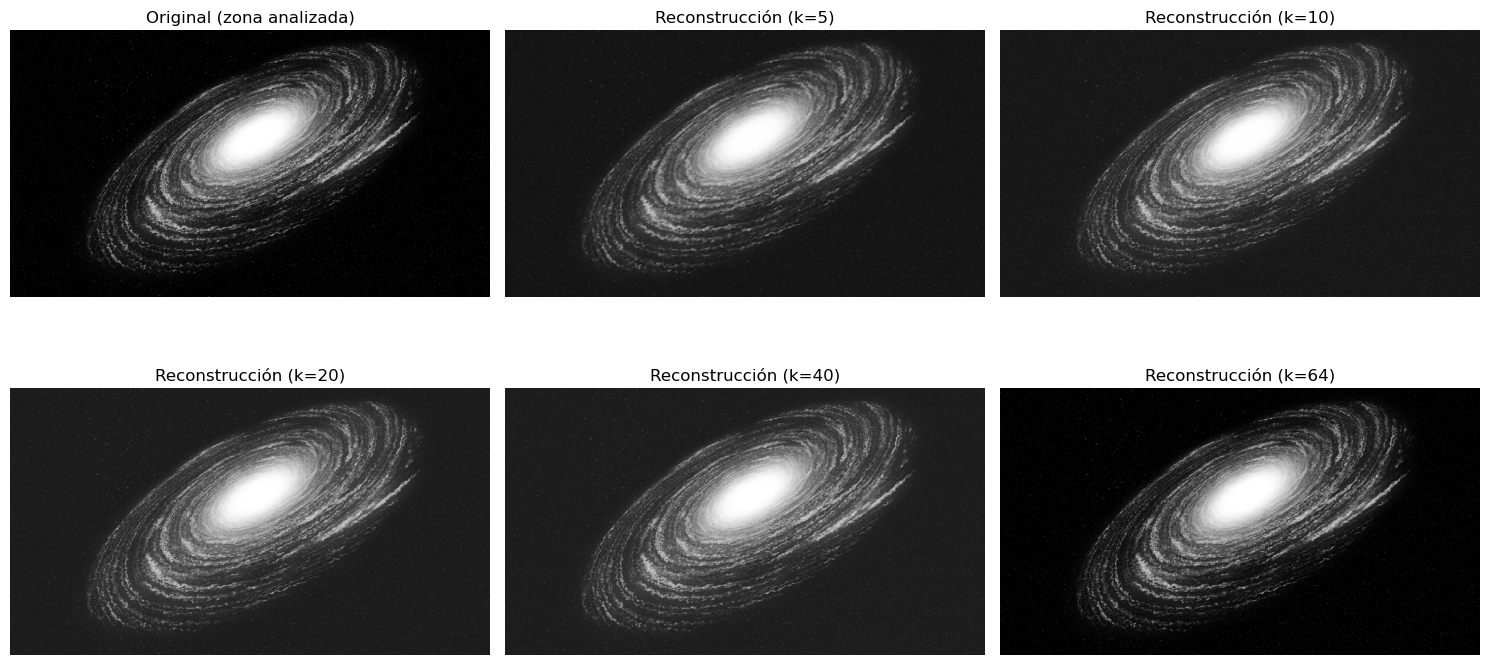

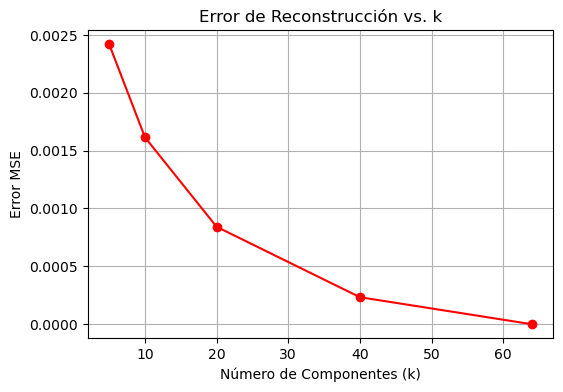

In [5]:
# Visualización de la imagen original y las reconstrucciones
plt.figure(figsize=(15,8))
n_plots = len(ks) + 1

plt.subplot(2, (n_plots+1)//2, 1)
plt.imshow(Igray[:reconstructions[ks[-1]].shape[0], :reconstructions[ks[-1]].shape[1]], cmap='gray')
plt.title("Original (zona analizada)")
plt.axis('off')

for i, k in enumerate(ks, start=2):
    plt.subplot(2, (n_plots+1)//2, i)
    plt.imshow(reconstructions[k], cmap='gray')
    plt.title(f"Reconstrucción (k={k})")
    plt.axis('off')
plt.tight_layout()
plt.show()

# %%
# Graficamos el error de reconstrucción (MSE) en función de k
plt.figure(figsize=(6,4))
plt.plot(list(errors.keys()), list(errors.values()), marker='o', color="red")
plt.xlabel("Número de Componentes (k)")
plt.ylabel("Error MSE")
plt.title("Error de Reconstrucción vs. k")
plt.grid(True)
plt.show()

# Parte 4:

## Factoración NNMF y Sistema de Recomendación con Filtrado Colaborativo

Construir un sistema de recomendación de filtro colaborativo para el conjunto de películas movies.csv, usando como base las recomendaciones de los usuarios en ratings.csv y el método de factoración no-negativa de matrices (NNMF). Para ello, puede usar las ideas que vimos en el notebook recommender.ipynb.

### Requerimientos:

Métricas y Selección de Vecinos:

- Seleccione una métrica apropiada (por ejemplo, similitud coseno) para calcular los vecinos más cercanos entre usuarios.
- Decida los parámetros de topNeigh (número de vecinos a considerar) y topMovies (número de películas a recomendar) según su criterio.

### Implementación:

- Utilice NNMF para descomponer la matriz de ratings y obtener las matrices latentes ( W ) (usuarios) y ( H ) (películas).

Construya una función recommender que reciba:
- userId: el identificador del usuario.
- topNeigh: el número de vecinos a considerar.
- topMovies: el número de películas a recomendar.

La función debe:
- Calcular la similitud entre el usuario y el resto usando la métrica seleccionada.
- Seleccionar los vecinos más similares.
- Predecir los ratings para las películas no vistas por el usuario.
- Devolver la lista o DataFrame de las películas recomendadas.

Ejemplo y Contraste:


Muestre ejemplos de varias recomendaciones para 3 usuarios diferentes.
Contraste las recomendaciones de su modelo con el top de películas mejor calificadas (globalmente) que el usuario no ha visto.

In [6]:
# Importar librerías y cargar datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import NMF
from sklearn.metrics.pairwise import cosine_similarity

# Cargar datasets
ratings = pd.read_csv('datasets/ratings.csv', header=0, sep=',')
movies = pd.read_csv('datasets/movies.csv', header=0, sep=',')

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (100836, 4)
Movies shape: (9742, 3)


# Preprocesamiento de Datos

Se crea la tabla pivot (usuarios x películas) y se filtra el dataset para seleccionar solo las películas con al menos 20 ratings.

In [7]:
# Crear la tabla pivot (usuarios x películas)
table = pd.pivot_table(ratings, index='userId', columns='movieId', values='rating', fill_value=0)
table = table.astype(int)
print("Tabla pivot shape:", table.shape)

# Filtrar películas con al menos 20 ratings
movie_stats = ratings.groupby('movieId')[['rating']].agg(['count', 'mean'])
movie_stats.columns = movie_stats.columns.droplevel()
cut = 20
movies_sample = movie_stats[movie_stats['count'] >= cut]
lista = list(movies_sample.index)

# Seleccionar solo las columnas correspondientes a las películas filtradas
df = table[[x for x in movies_sample.index]]
Xs = df.values
print("DataFrame filtrado shape:", df.shape)

Tabla pivot shape: (610, 9724)
DataFrame filtrado shape: (610, 1297)


# Factorización NNMF

Se realiza la descomposición de la matriz de ratings usando NNMF para obtener las matrices ( W ) (usuarios) y ( H ) (películas) en un espacio latente de dimensión ( k ).

In [8]:
# Factorización NNMF
k = 20
model = NMF(n_components=k, init='random', max_iter=1000, random_state=2024)
W = model.fit_transform(Xs)
H = model.components_
print("W shape:", W.shape, "H shape:", H.shape)

W shape: (610, 20) H shape: (20, 1297)


# Definición de Funciones de Recomendación

*Se definen dos funciones:*

* **recommender(userId, topNeigh, topMov):**
Calcula la similitud coseno entre usuarios a partir de la matriz ( W ), selecciona los vecinos más cercanos y predice ratings para películas no vistas utilizando un promedio ponderado de los ratings de los vecinos.
* **top_rated_by_user(userId, topN):**
Retorna el top de películas que el usuario ya calificó, ordenado según la calificación.

In [9]:
def recommender(userId, topNeigh=10, topMov=10):
    # Obtener el índice del usuario en el DataFrame
    try:
        user_index = df.index.get_loc(userId)
    except KeyError:
        raise ValueError(f"El userId {userId} no se encuentra en el DataFrame de ratings.")
    
    # Calcular la similitud coseno entre todos los usuarios usando sus vectores en W
    sim_matrix = cosine_similarity(W)
    sim_user = sim_matrix[user_index].copy()
    sim_user[user_index] = 0  # Excluir al propio usuario

    # Seleccionar los índices de los topNeigh vecinos
    neighbor_indices = np.argsort(sim_user)[::-1][:topNeigh]

    # Obtener las películas que el usuario no ha calificado
    user_ratings = df.values[user_index]
    unseen_movie_idx = np.where(user_ratings == 0)[0]

    # Predecir rating para cada película no vista usando promedio ponderado de ratings de vecinos
    predictions = {}
    for movie_idx in unseen_movie_idx:
        numerator = 0
        denominator = 0
        for neigh in neighbor_indices:
            rating = df.values[neigh, movie_idx]
            if rating > 0:  # Consideramos solo ratings existentes
                numerator += sim_user[neigh] * rating
                denominator += sim_user[neigh]
        predictions[movie_idx] = numerator / denominator if denominator > 0 else 0

    # Seleccionar las topMov películas con mayor rating predicho
    recommended_movie_idx = sorted(predictions, key=predictions.get, reverse=True)[:topMov]
    recommended_movieIds = df.columns[recommended_movie_idx]
    
    # Retornar la información de estas películas a partir del DataFrame movies
    recommendations = movies[movies['movieId'].isin(recommended_movieIds)]
    return recommendations

def top_rated_by_user(userId, topN=10):
    try:
        user_index = df.index.get_loc(userId)
    except KeyError:
        raise ValueError(f"El userId {userId} no se encuentra en el DataFrame de ratings.")
    
    user_ratings = df.values[user_index]
    # Obtener los índices de las películas ya calificadas
    rated_idx = np.where(user_ratings > 0)[0]
    if len(rated_idx) == 0:
        return pd.DataFrame()  # Usuario sin ratings previos
    # Ordenar índices por rating de forma descendente
    sorted_idx = rated_idx[np.argsort(user_ratings[rated_idx])[::-1]]
    top_movie_idx = sorted_idx[:topN]
    top_movieIds = df.columns[top_movie_idx]
    return movies[movies['movieId'].isin(top_movieIds)]

# Ejemplo de Uso para Todos los Usuarios

A continuación se recorre cada usuario del DataFrame df y se muestran:

* Las recomendaciones personalizadas basadas en NNMF y filtrado colaborativo.
* El top de películas ya calificadas por el usuario.

In [10]:
# Recorrer todos los usuarios y mostrar las recomendaciones
usuarios_ejemplo = [1, 2, 3]

# for user in df.index:
for user in usuarios_ejemplo:
    print(f"\n--- Recomendaciones para el usuario {user} ---")
    
    # Recomendaciones basadas en NNMF y vecinos colaborativos
    rec_model = recommender(user, topNeigh=10, topMov=10)
    print("Recomendaciones basadas en NNMF y vecinos colaborativos:")
    display(rec_model.sort_values(by='movieId'))
    
    # Top de películas ya calificadas por el usuario
    rec_top = top_rated_by_user(user, topN=10)
    print("Top de películas ya calificadas por el usuario:")
    display(rec_top.sort_values(by='movieId'))
    print("-" * 50)


--- Recomendaciones para el usuario 1 ---
Recomendaciones basadas en NNMF y vecinos colaborativos:


,movieId,title,genres
23,24,Powder (1995),Drama|Sci-Fi
167,198,Strange Days (1995),Action|Crime|Drama|Mystery|Sci-Fi|Thriller
249,288,Natural Born Killers (1994),Action|Crime|Thriller
276,317,"Santa Clause, The (1994)",Comedy|Drama|Fantasy
277,318,"Shawshank Redemption, The (1994)",Crime|Drama
395,454,"Firm, The (1993)",Drama|Thriller
809,1059,William Shakespeare's Romeo + Juliet (1996),Drama|Romance
889,1186,"Sex, Lies, and Videotape (1989)",Drama
901,1199,Brazil (1985),Fantasy|Sci-Fi
922,1221,"Godfather: Part II, The (1974)",Crime|Drama


Top de películas ya calificadas por el usuario:


,movieId,title,genres
701,919,"Wizard of Oz, The (1939)",Adventure|Children|Fantasy|Musical
705,923,Citizen Kane (1941),Drama|Mystery
783,1025,"Sword in the Stone, The (1963)",Animation|Children|Fantasy|Musical
786,1029,Dumbo (1941),Animation|Children|Drama|Musical
788,1031,Bedknobs and Broomsticks (1971),Adventure|Children|Musical
1431,1954,Rocky (1976),Drama
1480,2005,"Goonies, The (1985)",Action|Adventure|Children|Comedy|Fantasy
1493,2018,Bambi (1942),Animation|Children|Drama
1543,2078,"Jungle Book, The (1967)",Animation|Children|Comedy|Musical
3673,5060,M*A*S*H (a.k.a. MASH) (1970),Comedy|Drama|War


--------------------------------------------------

--- Recomendaciones para el usuario 2 ---
Recomendaciones basadas en NNMF y vecinos colaborativos:


...

--------------------------------------------------

--- Recomendaciones para el usuario 3 ---
Recomendaciones basadas en NNMF y vecinos colaborativos:


,movieId,title,genres
2,3,Grumpier Old Men (1995),Comedy|Romance
23,24,Powder (1995),Drama|Sci-Fi
43,47,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
89,101,Bottle Rocket (1996),Adventure|Comedy|Crime|Romance
95,107,Muppet Treasure Island (1996),Adventure|Children|Comedy|Musical
98,111,Taxi Driver (1976),Crime|Drama|Thriller
201,235,Ed Wood (1994),Comedy|Drama
249,288,Natural Born Killers (1994),Action|Crime|Thriller
291,333,Tommy Boy (1995),Comedy
916,1215,Army of Darkness (1993),Action|Adventure|Comedy|Fantasy|Horror


Top de películas ya calificadas por el usuario:


,movieId,title,genres
656,849,Escape from L.A. (1996),Action|Adventure|Sci-Fi|Thriller
974,1275,Highlander (1986),Action|Adventure|Fantasy
1054,1371,Star Trek: The Motion Picture (1979),Adventure|Sci-Fi
1190,1587,Conan the Barbarian (1982),Action|Adventure|Fantasy
1567,2105,Tron (1982),Action|Adventure|Sci-Fi
1701,2288,"Thing, The (1982)",Action|Horror|Sci-Fi|Thriller
2765,3703,"Road Warrior, The (Mad Max 2) (1981)",Action|Adventure|Sci-Fi|Thriller


--------------------------------------------------
